# Section A

In this Section, we consider a **probability distribution** proportional to


$$\pi(x, y) = {\large e^{- \alpha \left(x^{4} + y^{4}\right) - 0.5 x^{2} - 0.5 y^{2}}},\quad |x|<1 \text{ and } |y|<1$$

where $\alpha > 0$  is a fixed parameter and $(x,y)$ is a point  in the "heliport" square with edges $-1 < x < 1$ and $-1 < y <  1$. 

You will study different break-ups of $\pi(x,y)$ into one part that is used for proposing the sample and another one for accepting it, either in direct sampling or in Markov-chain sampling.

## A1: *Direct sampling*

Let random vector $\mathbf{X}=(X,Y)$, where $X,Y$ are drawn independently from the standard norm distribution. The probability density function for either $X$ or $Y$ is 

$$f_X(x) = f_Y(x) = \frac{1}{\sqrt{2\pi}} {\large e^{\large -\frac{1}{2}x^2}} = \frac{1}{\sqrt{2\pi}}\; g(x)$$

We sample points as follows:
1. Draw $X,Y \sim \mathcal{N}(0,1)$
2. Draw $U \sim \mathcal{U}(0, 1)$
3. **Accept** the sample if $U \leq A(x, y)$

The prob. density for an accepted $\mathbf{X}$ is 

$$\begin{aligned}
    f_{\mathbf{X}|\text{acc}}(x,y) &= \frac{f_\mathbf{X}(x,y)\; \Pr(\text{acc}|\mathbf{X}=(x,y))}{\Pr(\text{acc})}\\
    \\
    &= \frac{g(x)\; g(y)\; \Pr(U \leq A(x,y)|\mathbf{X}=(x,y))}{2\pi\,\Pr(\text{acc})}\\
    \\
    &= \frac{g(x)\; g(y)\; A(x,y)}{2\pi\,\Pr(\text{acc})}\\
\end{aligned}$$

Therefore, if we want $f_{\mathbf{X}|\text{acc}}(x,y) \propto \pi(x,y)$ the acceptance *level* must be proportinal to the ration
$$\begin{aligned}
A(x,y) &\propto \frac{\pi(x,y)}{g(x)\,g(y)}\\
&= \boxed{\large e^{-\alpha\,(x^4 + y^4)}}
\end{aligned}$$

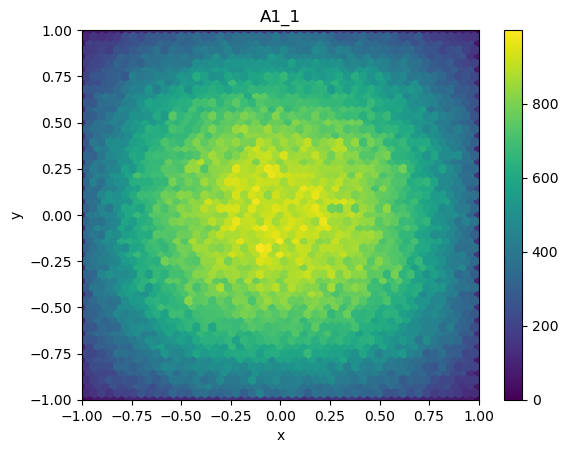

In [13]:
import random, math, matplotlib.pyplot as plt

def gauss_cut():
    while True:
        x = random.gauss(0.0, 1.0)
        if abs(x) <= 1.0:
            return x

alpha = 0.5
nsamples = 1000000
samples_x = []
samples_y = []
for sample in range(nsamples):
    while True:
        x = gauss_cut()
        y = gauss_cut()
        p = math.exp(- alpha * (x ** 4 + y ** 4))
        if random.uniform(0.0, 1.0) < p:
            break
    samples_x.append(x)
    samples_y.append(y)

plt.hexbin(samples_x, samples_y, gridsize=50, bins=1000)
plt.axis([-1.0, 1.0, -1.0, 1.0])
cb = plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('A1_1')
plt.savefig('plot_A1_1.png')
plt.show()